<a href="https://colab.research.google.com/github/comparativechrono/Comparative-birthograms-reveal-country-specific-rephasing-of-human-birth-seasonality/blob/main/Chow_amplitude_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

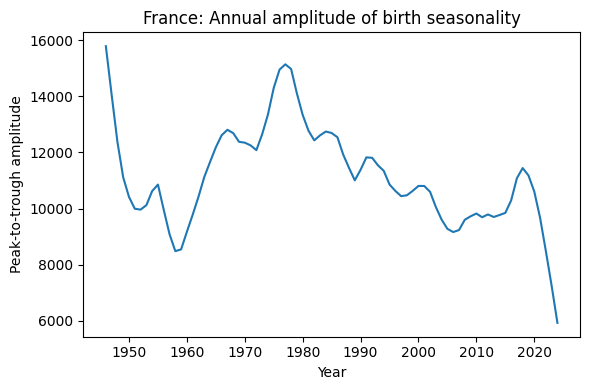

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)


France amplitude break year: 1994
France F-statistic at break year: 33.7650


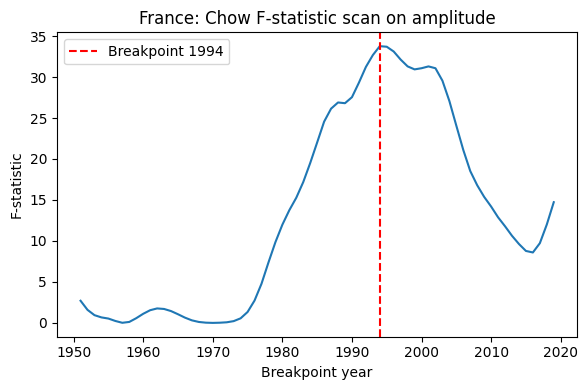

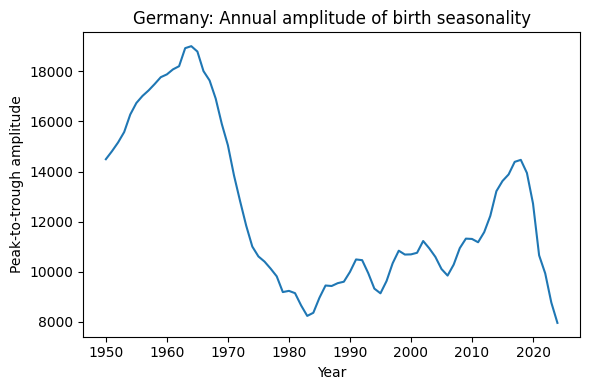

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)


Germany amplitude break year: 1971
Germany F-statistic at break year: 246.0810


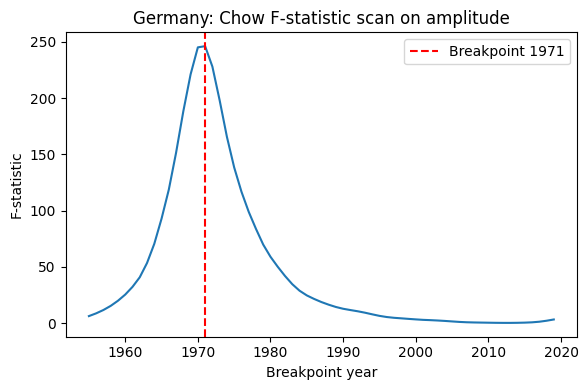

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
from scipy.stats import f

# Mapping from month names to numbers
MONTH_MAP = {
    "January":1, "February":2, "March":3, "April":4,
    "May":5, "June":6, "July":7, "August":8,
    "September":9, "October":10, "November":11, "December":12
}

def analyse_birth_series(csv_file, country_name):
    """Load monthly birth counts, compute annual amplitude and Chow break point."""
    # 1. Read data and create monthly date index
    df = pd.read_csv(csv_file, header=None, names=['Year','Month','Births','Extra'])
    df['Month_num'] = df['Month'].map(MONTH_MAP)
    df['Date'] = pd.to_datetime(
        df['Year'].astype(str) + '-' +
        df['Month_num'].astype(str).str.zfill(2) + '-01'
    )
    df = df.sort_values('Date').set_index('Date')
    births = df['Births'].astype(float)

    # 2. Decompose with STL to get seasonal component
    stl = STL(births, period=12, robust=True)
    res = stl.fit()
    seasonal = res.seasonal

    # 3. Compute annual peak-to-trough amplitude
    amplitude = seasonal.groupby(seasonal.index.year).agg(lambda x: x.max() - x.min())

    # 4. Plot amplitude
    plt.figure(figsize=(6,4))
    plt.plot(amplitude.index, amplitude.values)
    plt.title(f'{country_name}: Annual amplitude of birth seasonality')
    plt.xlabel('Year')
    plt.ylabel('Peak-to-trough amplitude')
    plt.tight_layout()
    plt.show()

    # 5. Chow break-point scan on amplitude series
    y = amplitude
    X = sm.add_constant(pd.Series(np.ones_like(y), index=y.index))  # constant-only model
    model_full = sm.OLS(y, X).fit()
    rss_full = (model_full.resid**2).sum()
    n = len(y)
    k = 1  # number of regressors (constant)

    # scan candidate break years (avoid first/last 5 years)
    start_year = int(y.index.min() + 5)
    end_year   = int(y.index.max() - 5)
    candidate_years = np.arange(start_year, end_year + 1)

    F_vals, p_vals = [], []
    for year in candidate_years:
        pre_mask = y.index <= year
        post_mask = y.index > year
        # skip if not enough data on either side
        if pre_mask.sum() <= k or post_mask.sum() <= k:
            F_vals.append(np.nan)
            p_vals.append(np.nan)
            continue
        pre_res  = sm.OLS(y[pre_mask], X.loc[pre_mask]).fit()
        post_res = sm.OLS(y[post_mask], X.loc[post_mask]).fit()
        rss_split = (pre_res.resid**2).sum() + (post_res.resid**2).sum()
        F_stat = ((rss_full - rss_split) / k) / (rss_split / (n - 2*k))
        F_vals.append(F_stat)
        p_vals.append(1 - f.cdf(F_stat, k, n - 2*k))

    # 6. Construct results and identify break
    chow_results = pd.DataFrame({
        'Year': candidate_years,
        'F': F_vals,
        'p': p_vals
    }).set_index('Year')
    break_year = chow_results['F'].idxmax()
    break_fstat = chow_results.loc[break_year, 'F']
    print(f'{country_name} amplitude break year: {break_year}')
    print(f'{country_name} F-statistic at break year: {break_fstat:.4f}')

    # 7. Plot F-statistic scan
    plt.figure(figsize=(6,4))
    plt.plot(chow_results.index, chow_results['F'])
    plt.axvline(break_year, color='red', linestyle='--', label=f'Breakpoint {break_year}')
    plt.title(f'{country_name}: Chow F-statistic scan on amplitude')
    plt.xlabel('Breakpoint year')
    plt.ylabel('F-statistic')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return amplitude, chow_results, break_year

# Run analysis for the French and German datasets
amp_france, chow_france, break_france = analyse_birth_series('french data.csv', 'France')
amp_germany, chow_germany, break_germany = analyse_birth_series('german data.csv', 'Germany')